<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Bagging Intuition</b>
</h1>

<div style="font-family:'Times New Roman';">

<b>Goal:</b>

<ol>
<li>Understand why a single Decision Tree can overfit.</li>
<li>Understand the idea behind Bagging.</li>
<li>See how multiple trees reduce variance.</li>
<li>Prepare for Random Forest.</li>
</ol>

In this notebook, I'll understand why using many trees is often better than relying on a single tree.

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The Problem with a Single Tree</b>
</h2>

<div style="font-family:'Times New Roman';">

A single Decision Tree can easily memorize the training data.

Because of this, small changes in the dataset can lead to completely different trees.

This makes Decision Trees a <b>high variance</b> model.

</div>

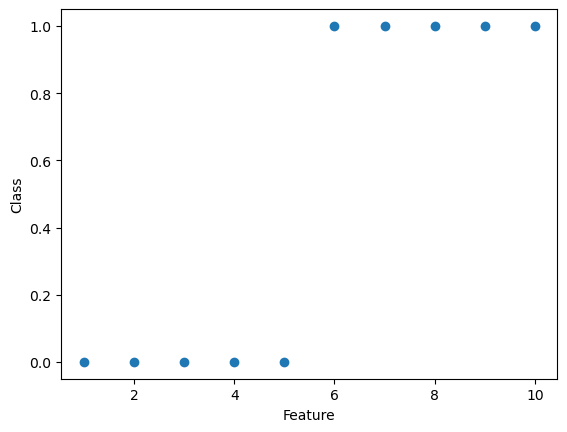

In [2]:
# small example dataset

X = np.arange(1,11)

y = [0,0,0,0,0,1,1,1,1,1]

plt.scatter(X,y)

plt.xlabel("Feature")
plt.ylabel("Class")

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Imagine Training One Tree</b>
</h2>

<div style="font-family:'Times New Roman';">

A single tree will learn from this dataset and create its own rules.

If we slightly change the training data, the learned tree may look very different.

This instability is one of the reasons Decision Trees tend to overfit.

</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is Bootstrap Sampling?</b>
</h2>

<div style="font-family:'Times New Roman';">

- Instead of training one tree on the entire dataset, we create multiple random datasets.

- These datasets are created by sampling the original data <b>with replacement</b>.

- Some samples may appear multiple times while others may not appear at all.

</div>

In [3]:
# original dataset

data = np.arange(1,11)

print(data)

[ 1  2  3  4  5  6  7  8  9 10]


In [4]:
# bootstrap sample 1

sample1 = np.random.choice(data, size=len(data), replace=True)

sample1

array([ 5,  3,  2, 10,  8,  2,  6,  7,  8,  7])

In [5]:
# bootstrap sample 2

sample2 = np.random.choice(data, size=len(data), replace=True)

sample2

array([ 6,  8, 10,  7,  3,  9, 10,  3,  4,  3])

In [6]:
# bootstrap sample 3

sample3 = np.random.choice(data, size=len(data), replace=True)

sample3

array([ 6,  9,  8, 10,  8,  6,  4,  2,  5,  7])

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Observation</b>
</h2>

<div style="font-family:'Times New Roman';">

Each sample is slightly different from the original dataset.

Because the training data changes, each Decision Tree will learn slightly different rules.

</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Majority Voting</b>
</h2>

<div style="font-family:'Times New Roman';">

Instead of trusting a single tree, we ask multiple trees to make a prediction.

The final prediction is chosen using majority voting.

</div>

In [7]:
# predictions from different trees

predictions = [1,1,0,1,0]

predictions

[1, 1, 0, 1, 0]

In [8]:
# majority vote

final_prediction = max(
    set(predictions),
    key=predictions.count
)

print("Final Prediction :", final_prediction)

Final Prediction : 1


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why Bagging Works</b>
</h2>

<div style="font-family:'Times New Roman';">

A single tree may make mistakes.

However, when many trees vote together, random mistakes often cancel out.

This usually leads to better and more stable predictions.

</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Conclusion</b>
</h2>

<div style="font-family:'Times New Roman';">

<ul>
<li>Decision Trees can overfit the training data.</li>
<li>Bagging creates multiple datasets using bootstrap sampling.</li>
<li>A separate tree is trained on each dataset.</li>
<li>The final prediction is obtained using voting.</li>
<li>Bagging reduces variance and improves stability.</li>
</ul>

Bagging Workflow:

<pre>
Original Dataset
        ↓
Bootstrap Samples
        ↓
Multiple Trees
        ↓
Voting
        ↓
Final Prediction
</pre>

Random Forest is built on this exact idea.

</div>